In [1]:
library(readxl)
library(dplyr)
library(stringr)
library(reshape2)
library(ComplexHeatmap)
library(ggplot2)
library(colorspace)
library(plotly)
library(tidyr)
library(magrittr)
library(audiometry)
library(trackViewer)
library(readr)
library(chorddiag)

Warning message:
"package 'dplyr' was built under R version 4.3.2"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: grid

ComplexHeatmap version 2.16.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))



A

In [3]:
df <- read_excel("MPZL2 Source Data.xlsx",sheet=7)

In [7]:
df_delta <- df %>%
  group_by(Group) %>%
  arrange(Age) %>%
  mutate(
    Low_delta  = Low  - Low[Age == 0],
    Mid_delta  = Mid  - Mid[Age == 0],
    High_delta = High - High[Age == 0]
  ) %>%
  ungroup()

In [8]:
human_match <- df_delta %>%
  filter(Group == "Human",
         Age %in% c(0, 0.5, 1)) %>%
  select(Age,
         Low_delta,
         Mid_delta,
         High_delta)

mouseA_match <- df_delta %>%
  filter(Group == "MouseA") %>%
  select(Age,
         Low_delta,
         Mid_delta,
         High_delta)

mouseB_match <- df_delta %>%
  filter(Group == "MouseB") %>%
  select(Age,
         Low_delta,
         Mid_delta,
         High_delta)

In [9]:
human_vec <- human_match %>%
  select(-Age) %>%
  as.matrix() %>%
  as.vector()

mouseA_vec <- mouseA_match %>%
  select(-Age) %>%
  as.matrix() %>%
  as.vector()

mouseB_vec <- mouseB_match %>%
  select(-Age) %>%
  as.matrix() %>%
  as.vector()

In [10]:
cosine_similarity <- function(x, y){
  
  sum(x * y) /
    (sqrt(sum(x^2)) * sqrt(sum(y^2)))
}

cos_A <- cosine_similarity(human_vec,
                           mouseA_vec)

cos_B <- cosine_similarity(human_vec,
                           mouseB_vec)

In [11]:
regions <- c(
  "Low_delta",
  "Mid_delta",
  "High_delta"
)
result_A <- lapply(regions, function(r){
  
  x <- human_match[[r]]
  y <- mouseA_match[[r]]
  
  tibble(
    Model = "MouseA",
    
    Region = gsub("_delta", "", r),
    
    Correlation = cor(x, y),
    
    CosineSimilarity =
      sum(x * y) /
      (sqrt(sum(x^2)) * sqrt(sum(y^2)))
  )
})

result_A <- bind_rows(result_A)


result_B <- lapply(regions, function(r){
  
  x <- human_match[[r]]
  y <- mouseB_match[[r]]
  
  tibble(
    Model = "MouseB",
    
    Region = gsub("_delta", "", r),
    
    Correlation = cor(x, y),
    
    CosineSimilarity =
      sum(x * y) /
      (sqrt(sum(x^2)) * sqrt(sum(y^2)))
  )
})

result_B <- bind_rows(result_B)

overall_result <- tibble(
  
  Model = c(
    "MouseA",
    "MouseB"
  ),
  
  Region = "Overall",
  
  Correlation = c(
    cor(human_vec, mouseA_vec),
    cor(human_vec, mouseB_vec)
  ),
  
  CosineSimilarity = c(
    cosine_similarity(human_vec,
                      mouseA_vec),
    
    cosine_similarity(human_vec,
                      mouseB_vec)
  )
)

final_result <- bind_rows(
  overall_result,
  result_A,
  result_B
)

final_result

Model,Region,Correlation,CosineSimilarity
<chr>,<chr>,<dbl>,<dbl>
MouseA,Overall,0.7327194,0.8787840
MouseB,Overall,0.9102354,0.9561870
MouseA,Low,0.7561940,0.8757583
MouseA,Mid,0.7685362,0.8971188
MouseA,High,0.9516709,0.9780795
MouseB,Low,0.9372405,0.9607086
MouseB,Mid,0.9636726,0.9801859
MouseB,High,0.8692841,0.9454514


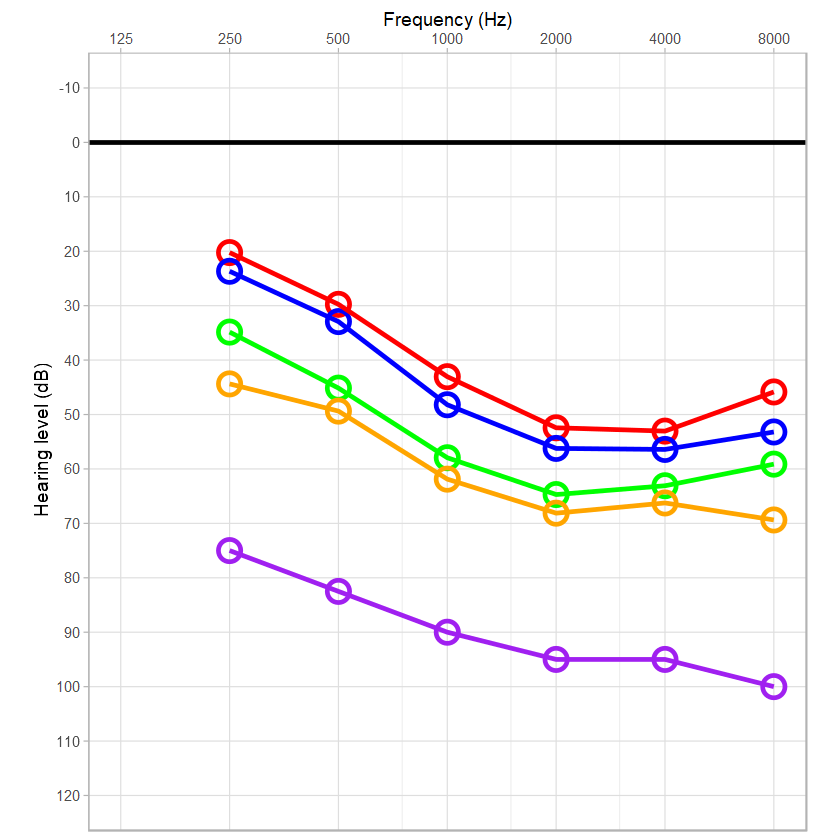

In [12]:
human <- read_excel("MPZL2 Source Data.xlsx",sheet=2)

human_long <- human %>%
  pivot_longer(cols = -year,names_to = "f",values_to = "t")

audio_summary <- human_long %>%
  mutate(
    time = case_when(
      year == 0 ~ "0",
      year == 1 ~ "1",
      year == 2 ~ "2",
      year == 3 ~ "3",
      year == 4 ~ "4")
    ) %>%
  group_by(time, f) %>%
  summarise(t = mean(t, na.rm = TRUE),.groups = "drop")

audio_summary$f <- gsub("Hz", "", audio_summary$f)
audio_summary$f <- as.numeric(audio_summary$f)


gg_pta(audio_summary,
       xlab = "Frequency (Hz)",
       ylab = "Hearing level (dB)") +
  geom_point(aes(x = f,y = t,color = factor(time),shape = factor(time)),
    size = 5,stroke = 1.5) +
  geom_line(aes(x = f,y = t,color = factor(time),linetype = factor(time)),
    linewidth = 1) +
  scale_color_manual(values = c("red","blue","green","orange","purple")) +
  scale_shape_manual(values = rep(1,5)) +
  scale_linetype_manual(values = rep(1,5)) +
  theme(legend.position = "none")

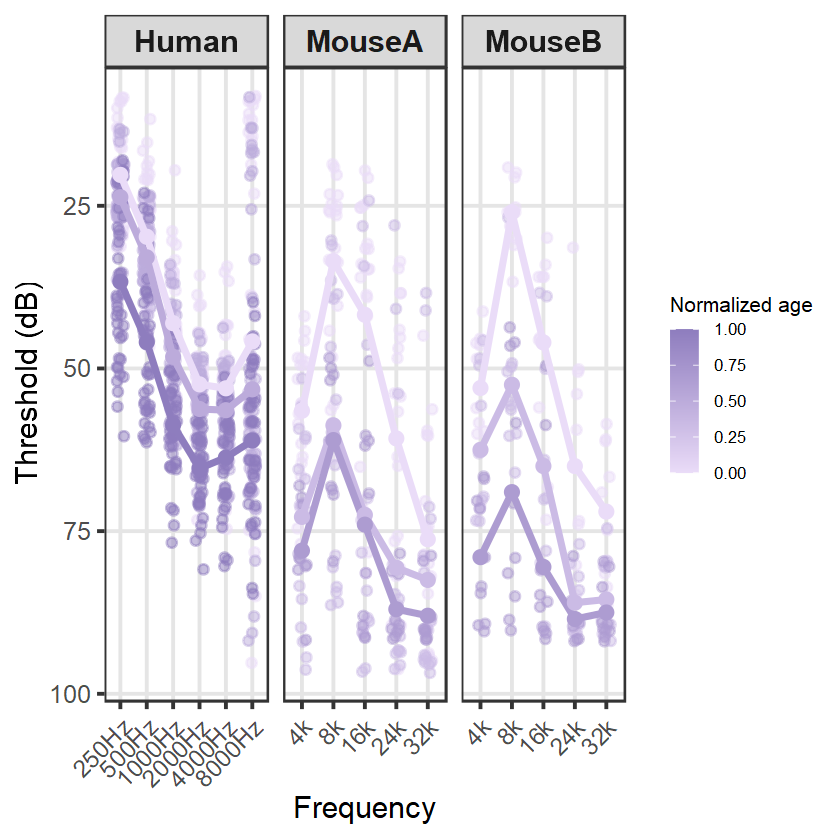

In [13]:
human <- read_excel("MPZL2 Source Data.xlsx",sheet=2)
mouse <- read_excel("MPZL2 Source Data.xlsx",sheet=5)

human <- human[c(1:136),]
human[c(129:136),1] <- 2

human_long <- human %>%
  
  pivot_longer(
    cols = -year,
    names_to = "Frequency",
    values_to = "Threshold"
  ) %>%
  
  mutate(
    Species = "Human",
    Model = "Human",
    Age = year / max(year)
  ) %>%
  
  select(
    Species,
    Model,
    Age,
    Frequency,
    Threshold
  )

human_long <- na.omit(human_long)


mouse <- mouse[mouse$Week!=6,]

mouse_long <- mouse %>%
  
  pivot_longer(
    cols = c(`4k`,
             `8k`,
             `16k`,
             `24k`,
             `32k`),
    names_to = "Frequency",
    values_to = "Threshold"
  ) %>%
  
  mutate(
    Species = "Mouse",
    Age = case_when(
      Model == "A" ~ (Week-4) / 12,
      Model == "B" ~ (Week-4) / 12
    )
  ) %>%
  
  select(
    Species,
    Model,
    Age,
    Frequency,
    Threshold
  )

all_long <- bind_rows(human_long, mouse_long)

human_levels <- c("250Hz","500Hz","1000Hz","2000Hz","4000Hz","8000Hz")
mouse_levels <- c("4k","8k","16k","24k","32k")

all_long$Frequency <- factor(
  all_long$Frequency,
  levels = c(human_levels,mouse_levels)
)

all_long <- all_long %>%
  mutate(
    Group = case_when(
      Species == "Human" ~ "Human",
      Species == "Mouse" & Model == "A" ~ "MouseA",
      Species == "Mouse" & Model == "B" ~ "MouseB")
  )




mean_df <- all_long %>%
  group_by(Group,Age,Frequency) %>%
  summarise(Mean = mean(Threshold,na.rm = TRUE),.groups = "drop")




ggplot() +
  geom_jitter(data = all_long,
            aes(x = Frequency,y = Threshold,color = Age),
            width = 0.15,size = 2,alpha = 0.5) +
  geom_line(data = mean_df,
          aes(x = Frequency,y = Mean,group = Age,color = Age),
          linewidth = 1.5) +
  geom_point(data = mean_df,
           aes(x = Frequency,y = Mean,color = Age),size = 3) +
  facet_wrap(~Group,scales = "free_x") +
  scale_color_gradient(low = "#EADCF8",high = "#8E7DBE")+
  scale_y_reverse() +
  theme_bw(base_size = 18) +
  labs(x = "Frequency",y = "Threshold (dB)",color = "Normalized age") +
  theme(
    strip.text = element_text(size = 18,face = "bold"),
    axis.text.x = element_text(angle = 45,hjust = 1),
    panel.grid.major = element_line(color = "grey90"),
    panel.grid.minor = element_blank(),
    legend.title = element_text(size = 12),
    legend.text = element_text(size = 10)
  )

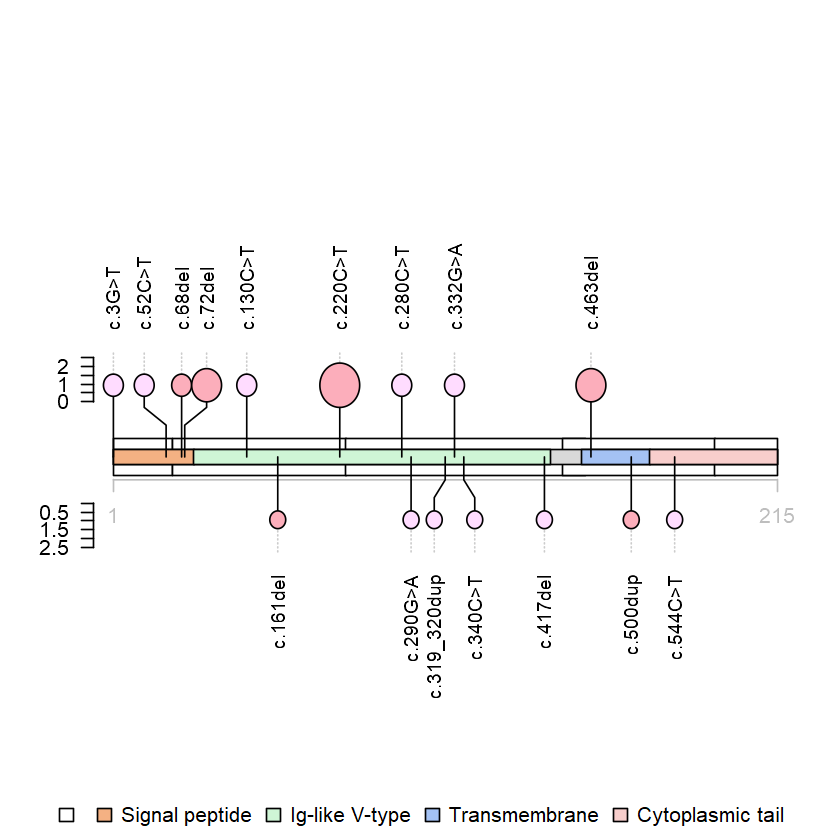

In [15]:
mut1 <- c("c.3G>T","c.52C>T","c.68del","c.72del","c.130C>T","c.161del","c.220C>T","c.280C>T","c.290G>A","c.319_320dup",
          "c.332G>A","c.340C>T","c.417del","c.463del","c.500dup","c.544C>T")

count <-c(1,1,1,1,1,1,1,1,1,1,
          1,1,1,1,1,1)

loc <- c(1,18,23,24,44,54,74,94,97,108,
         111,114,140,155,168,182)


col=c("#ffdcff","#ffdcff","#FCAEBB","#FCAEBB","#ffdcff","#FCAEBB","#FCAEBB","#ffdcff","#ffdcff","#ffdcff",
      "#ffdcff","#ffdcff","#ffdcff","#FCAEBB","#FCAEBB","#ffdcff")


exon <- GRanges("chr1",
                IRanges(c(1,20,76,146,195),
                        width=c(20,57,78,50,22)),
                fill = c("white","white","white","white","white"),
                height=0.05)

protein_bg <- GRanges("chr1",IRanges(start=1, end=215),fill=c("#d9d9d9"),height=0.02)
ig_domain <- GRanges("chr1",IRanges(start=27, end=142, names="Ig-like V-type"),fill="#CFF5D6",height=0.02)
signal_peptide <- GRanges("chr1",IRanges(start=1, end=27, names="Signal peptide"),
                          fill="#F4B183",height=0.02)
tm_domain <- GRanges("chr1",IRanges(start=152, end=174, names="Transmembrane"),
                     fill="#A4C2F4",height=0.02)
cyto_tail <- GRanges("chr1",IRanges(start=174, end=215, names="Cytoplasmic tail"),
                     fill="#F8CECC",height=0.02)

features <- c(exon,protein_bg,signal_peptide,ig_domain,tm_domain,cyto_tail)


mpzl2.gr <- GRanges("chr1",IRanges(loc,width=1,names=mut1),
                    color=col,score=count*1.000000000001)

mpzl2.gr$SNPsideID <- "bottom"

target <- c("c.3G>T","c.52C>T","c.68del","c.72del","c.130C>T","c.220C>T","c.280C>T","c.332G>A","c.463del")
mpzl2.gr$SNPsideID[names(mpzl2.gr) %in% target] <- "top"

mpzl2.gr$cex <- 0.8
mpzl2.gr$cex[names(mpzl2.gr) %in% target] <- 1
mpzl2.gr$cex[names(mpzl2.gr) == "c.220C>T"] <- 2
mpzl2.gr$cex[names(mpzl2.gr) %in% c("c.463del","c.72del")] <- 1.5


mpzl2.gr$label.parameter.gp <- gpar(fontsize=11)

lolliplot(mpzl2.gr,features,ranges=GRanges("chr1",IRanges(1,215)),xaxis=c(1,215),ylab=FALSE)

In [16]:
m2 <- matrix(c(1,1,5,0,1,130,0,2,14,
               0,0,0,23,0,3,0,0,0,
               0,0,0,4,0,0,0,0,0,
               0,0,0,10,0,0,2,0,0,
               0,0,0,3,0,0,1,0,0),
             byrow=TRUE,
             nrow=5,ncol=9)
dimnames(m2) <- list(have = c("East Asian","Middle Eastern","African","European","American"),
                     prefer = c("c.3G>T","c.52C>T","c.68del","c.72del","c.130C>T","c.220C>T","c.280C>T","c.332G>A","c.463del"))
groupColors <- c("#c0ffff", "#FFDD89", "#957244", "#F26223","#d2ff88",
                 "#00bfff","#9063CD","#FDFDaf","#FF9DFF","#cec5f1","#D1F0DC","#568256","#ffaf00","#ffe900")
chorddiag(m2,type="bipartite", groupColors = groupColors, groupnamePadding = 10,groupnameFontsize = 10,showTicks=FALSE,
          categoryNames = FALSE)

HTML widgets cannot be represented in plain text (need html)

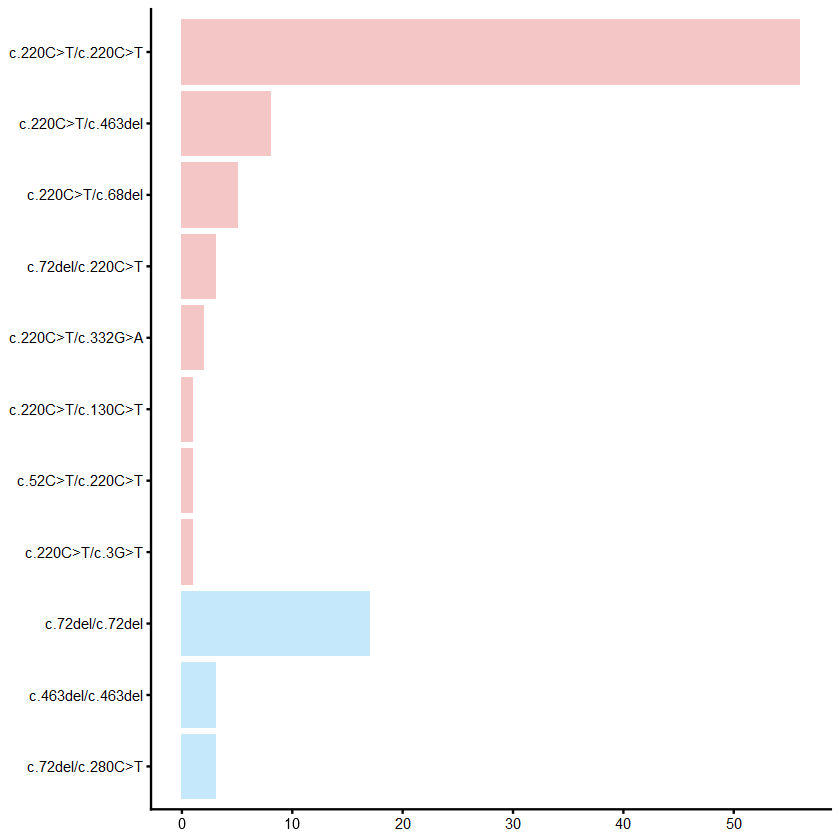

In [18]:
data <- read_excel("MPZL2 Source Data.xlsx",sheet=8)

data$group <- ifelse(1:nrow(data) <= 3, "Group1", "Group2")
data <- data %>%
  arrange(group, X2)
data$X1 <- factor(data$X1, levels = data$X1)

ggplot(data, aes(x = X1, y = X2, fill = group)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("Group1" = "#C6E8FB",
                               "Group2" = "#f5c6c6")) +
  scale_y_continuous(breaks = seq(0, max(data$X2, na.rm = TRUE), by = 10)) +
  theme_classic()+
  coord_flip()+
  theme(axis.title.x = element_blank(),axis.title.y = element_blank(),legend.position = "none")